# EDA 1 — Data overview & structure

**Project:** *Identification des utilisateurs de Copilote* (MOD 7.2, BE séances 1-3).
The goal is to predict which **user** (`util`) produced a session of Copilote
usage, from the sequence of actions in that session and the browser used.

This notebook answers the first question of the analysis: **what do the raw
files look like and how are they organised?**

## Loading the raw data

Each row of `train.csv` / `test.csv` is a *session*. The first columns are the
metadata (`util`, `navigateur`), everything after that is one action token per
column. Sessions have very different lengths, so pandas pads the shorter lines
with `NaN`: this is expected, not missing data.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from be_ml.data import read_ds, session_features, filter_action, extract, SCREEN_RE, CONFIG_RE, CHAINE_RE

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 160)

In [3]:
train = read_ds("train")
test = read_ds("test")
print("train:", train.shape, "| test:", test.shape)

train: (3279, 14470) | test: (324, 7726)


Here is the head of the training set (only the first few action columns):

In [ ]:
train.iloc[:50, :20]

,util,navigateur,0,1,2,3,4,5
0,nuh,Firefox,Création d'un écran(infologic.core.accueil.Acc...,Affichage d'une dialogue,Exécution d'un bouton,Fermeture d'une dialogue,Affichage d'une dialogue,Exécution d'un bouton
1,muz,Google Chrome,Création d'un écran(infologic.core.gui.control...,Création d'un écran(infologic.core.gui.control...,t5,Sélection d’un onglet(infologic.orga.modules.O...,t10,Exécution d'un bouton
2,zrx,Microsoft Edge,Affichage d'une dialogue(infologic.core.gui.co...,Exécution d'un bouton,Chainage,Fermeture d'une dialogue,Affichage d'une dialogue(infologic.acti.module...,Clic sur une grille d'historique de recherche
3,pou,Firefox,Création d'un écran(infologic.core.gui.control...,t5,Exécution d'un bouton(MAINT),Affichage d'une dialogue,Fermeture d'une dialogue,Double-clic
4,ald,Google Chrome,Affichage d'une dialogue(infologic.acti.module...,t5,Exécution d'un bouton,Fermeture d'une dialogue,t10,Entrée en saisie dans un formulaire
5,shh,Firefox,Création d'un écran(infologic.crm.modules.CRM_...,Création d'un écran(infologic.acti.modules.AT_...,Exécution d'un bouton<STD>,Action de table,Exécution d'un bouton,Action de table
6,fwf,Firefox,Exécution d'un bouton,t5,Exécution d'un bouton(fr.infologic.infoc.clien...,t10,Raccourci(fr.infologic.infoc.client.forms.Laun...,Saisie dans un champ
7,slq,Google Chrome,Exécution d'un bouton,Exécution d'un bouton,t5,Exécution d'un bouton(fr.infologic.achats.clie...,t10,Saisie dans un champ(fr.infologic.ventes.clien...
8,cje,Google Chrome,Création d'un écran(infologic.core.accueil.Acc...,t5,Sélection d’un onglet,Exécution d'un bouton,Chainage,Filtrage / Tri
9,byo,Firefox,Création d'un écran(infologic.core.accueil.Acc...,t5,Exécution d'un bouton,Chainage,Affichage d'une dialogue,Exécution d'un bouton


## Global structural summary

In [5]:
summary = pd.DataFrame(
    {
        "rows (sessions)": [len(train), len(test)],
        "raw columns": [train.shape[1], test.shape[1]],
        "action columns": [train.shape[1] - 2, test.shape[1] - 1],
        "distinct users": [train["util"].nunique(), np.nan],
        "distinct browsers": [train["navigateur"].nunique(), test["navigateur"].nunique()],
    },
    index=["train", "test"],
)
summary

,rows (sessions),raw columns,action columns,distinct users,distinct browsers
train,3279,14470,14468,247.0,4
test,324,7726,7725,NaN,4


The number of raw columns is driven by the single longest session, so almost
all of the table is padding. The real quantity of information is the number of
non-null action tokens.

In [6]:
train_tokens = int(train.iloc[:, 2:].notna().sum().sum())
test_tokens = int(test.iloc[:, 1:].notna().sum().sum())
pad_share = 1 - train_tokens / (len(train) * (train.shape[1] - 2))
print(f"non-null action tokens -> train: {train_tokens:,} | test: {test_tokens:,}")
print(f"share of padding (NaN) in the train table: {pad_share:.2%}")
print(f"average session length: {train_tokens / len(train):.1f} tokens")

non-null action tokens -> train: 2,787,933 | test: 265,177
share of padding (NaN) in the train table: 94.12%
average session length: 850.2 tokens


## How long are the sessions?

Session length (number of actions) is the first candidate feature. It is highly
skewed: a few users keep a single session open for a very long time.

In [7]:
n_actions = train.iloc[:, 2:].notna().sum(axis=1)
n_actions.describe().round(1).to_string()

'count     3279.0\nmean       850.2\nstd       1212.3\nmin          2.0\n25%        192.0\n50%        423.0\n75%       1019.0\nmax      14468.0'

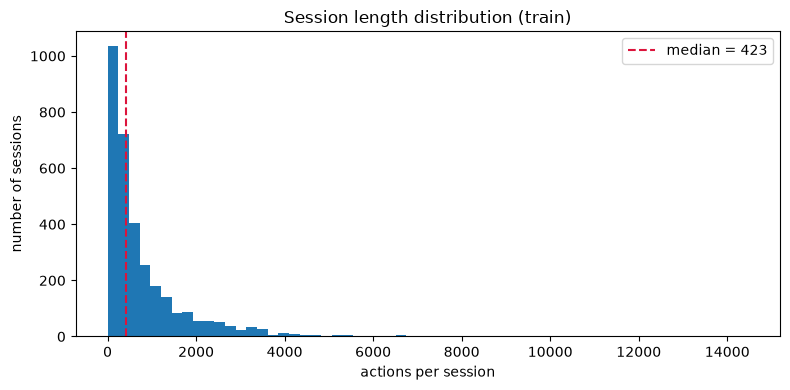

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(n_actions, bins=60)
ax.axvline(n_actions.median(), color="crimson", ls="--", label=f"median = {n_actions.median():.0f}")
ax.set(xlabel="actions per session", ylabel="number of sessions", title="Session length distribution (train)")
ax.legend()
plt.tight_layout()
plt.show()

## Sessions per user

There are far fewer users than sessions: most users appear in several sessions.
This is essential for validation — **rows are not independent users**, so a
random row split leaks user information and overestimates performance.

In [9]:
sessions_per_user = train["util"].value_counts()
print(sessions_per_user.describe().round(1).to_string())
print("\nsessions per user (sorted) — first 10:")
print(sessions_per_user.head(10).to_string())

count    247.0
mean      13.3
std        8.9
min        4.0
25%        7.0
50%       12.0
75%       16.0
max       75.0

sessions per user (sorted) — first 10:
util
skm    75
slq    71
cjr    46
flj    42
hjs    37
vfo    35
shh    34
nqg    34
fwf    33
kwi    31


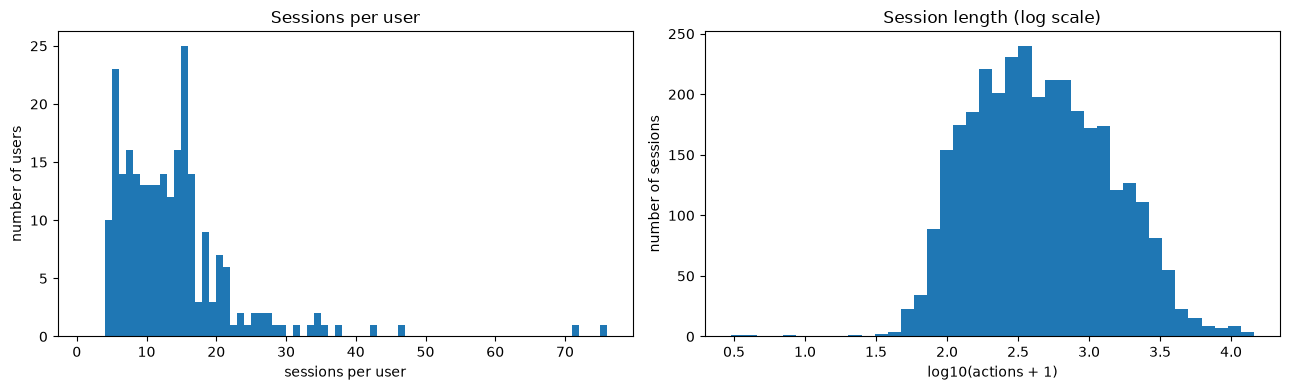

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].hist(sessions_per_user, bins=range(1, sessions_per_user.max() + 2))
axs[0].set(xlabel="sessions per user", ylabel="number of users", title="Sessions per user")
axs[1].hist(np.log10(n_actions + 1), bins=40)
axs[1].set(xlabel="log10(actions + 1)", ylabel="number of sessions", title="Session length (log scale)")
plt.tight_layout()
plt.show()

## Takeaways

- A **row is a session**, not a user. The target `util` has 247 distinct values,
  and each user owns several sessions (4 to 75).
- The table is mostly padding; the meaningful signal is ~2.8M action tokens.
- Session length is strongly right-skewed and correlated with the number of
  time markers.
- Because several rows share the same user, any train/validation split must be
  done **by user** to avoid leakage.

**Next:** `EDA_02_target_browser.ipynb` studies the target and the browser.